# Hydro Data: First Inspection

This notebook provides a comprehensive introduction to loading and analyzing hydrodynamic simulation data using Mera.jl. You'll learn the fundamentals of working with RAMSES hydro data and AMR (Adaptive Mesh Refinement) structures.

## Learning Objectives

- Load and inspect hydrodynamic simulation data
- Understand AMR (Adaptive Mesh Refinement) grid structures  
- Analyze basic properties and statistics of hydro data
- Handle different variable types and unit conversions
- Work with IndexedTables data structures
- Apply memory management best practices

## Quick Reference: Essential Hydro Functions

This section provides a comprehensive reference of key Mera.jl functions for hydro data analysis.

### Data Loading Functions
```julia
# Load simulation metadata with hydro information
info = getinfo(output_number, "path/to/simulation")
info = getinfo(300, "/path/to/sim")                    # Specific output
info = getinfo("/path/to/sim")                         # First output

# Load hydro data - basic usage
gas = gethydro(info)                                   # Load all variables, all levels

```

### Data Exploration Functions
```julia
# Analyze data structure and properties
overview_amr = amroverview(gas)                        # AMR grid structure analysis
data_overview = dataoverview(gas)                     # Statistical overview of variables
usedmemory(gas)                                        # Memory usage analysis

# Explore object structure
viewfields(gas)                                        # View HydroDataType structure
viewfields(info.descriptor)                           # View descriptor properties
propertynames(gas)                                     # List all available fields
```

### Variable and Descriptor Management
```julia
# Access and modify variable descriptors
info.descriptor.hydro                                  # Current hydro variable names
info.descriptor.hydro[2] = :vel_x                     # Customize variable names
propertynames(info.descriptor)                        # All descriptor properties

# Access predefined variables (always available)
# :rho, :vx, :vy, :vz, :p, :var6, :var7, ...
```

### IndexedTables Operations
```julia
# Work with data tables
using Mera.IndexedTables

# Select specific columns
select(gas.data, (:level, :cx, :cy, :cz, :rho))      # View spatial coordinates + density
select(data_overview, (:level, :mass, :rho_min, :rho_max)) # Statistical summary (table from before)

# Extract column data
column(data_overview, :mass)                          # Extract mass column as array
column(data_overview, :mass) * info.scale.Msol       # Convert to solar masses

# Transform data in-place
transform(data_overview, :mass => :mass => value->value * info.scale.Msol)
```

### Unit Conversion
```julia
# Access scaling factors
scale = gas.scale                                      # Shortcut to scaling factors
constants = gas.info.constants                        # Physical constants

```

### Memory Management
```julia
# Monitor and optimize memory usage
usedmemory(gas)                                        # Check current memory usage
gas = nothing; GC.gc()                                # Clear variable and garbage collect

```

### Common Analysis Workflow
```julia
# Standard hydro data analysis workflow
info = getinfo(300, "/path/to/simulation")            # Load simulation metadata
gas = gethydro(info)                                  # Load hydro data
usedmemory(gas)                                        # Check memory usage

# Analyze structure and properties
amr_overview = amroverview(gas)                        # AMR grid analysis
data_overview = dataoverview(gas)                     # Variable statistics
viewfields(gas)                                        # Explore data structure

# Convert units and extract specific data
scale = gas.scale                                      # Create scaling shortcut
density_gcm3 = select(gas.data, :rho) * scale.g_cm3   # Physical density
mass_dist = select(data_overview, (:level, :mass))    # Mass distribution by level
```

### Data Quality and Constraints
```julia
# Set physical constraints during loading
gas = gethydro(info, smallr=1e-11)                    # Minimum density floor
gas = gethydro(info, smallc=1e5)                      # Minimum sound speed

# Check data integrity
data_overview = dataoverview(gas)                     # Look for unrealistic values
select(data_overview, (:rho_min, :rho_max))          # Check density ranges
```

## Getting Started

This tutorial section will walk you through practical examples of hydro data analysis. We'll start with basic setup and progress through increasingly sophisticated analysis techniques.

### Initial Setup and Data Loading

We'll begin by loading simulation data and exploring its properties to understand:

- Basic simulation parameters and hydro configuration
- Available hydrodynamic variables and their organization  
- File structure and data layout
- AMR grid properties and refinement levels

### Package Import and Initial Setup

Let's start by importing Mera.jl and loading simulation information for output 300:

In [1]:
# Example-data root. Point this at your own simulation folder, or set the
# MERA_EXAMPLES environment variable; every path below is built from it.
MERA_EXAMPLES = get(ENV, "MERA_EXAMPLES", "/Volumes/FASTStorage/Simulations/Mera-Tests");

using Mera
info = getinfo(300, "$MERA_EXAMPLES/RAMSES/mw_L10");


*__   __ _______ ______   _______ 


|  |_|  |       |    _ | |   _   |
|       |    ___|   | || |  |_|  |
|       |   |___|   |_||_|       |
|       |    ___|    __  |       |
| ||_|| |   |___|   |  | |   _   |
|_|   |_|_______|___|  |_|__| |__|
Mera v1.8.0

[Mera]: 2026-08-06T10:42:25.069



Code: RAMSES


output [300] summary:
mtime: 2023-04-09T05:34:09
ctime: 2025-06-21T18:31:24.020
simulation time: 445.89 [Myr]
boxlen: 48.0 [kpc]
ncpu: 640
ndim: 3
cosmological:  false
-------------------------------------------------------
amr:           true
level(s): 6 - 10 --> cellsize(s): 750.0 [pc] - 46.88 [pc]
-------------------------------------------------------
hydro:         true
hydro-variables:  

7  --> (:rho, :vx, :vy, :vz, :p, :scalar_00, :scalar_01)
hydro-descriptor: (:density, :velocity_x, :velocity_y, :velocity_z, :pressure, :scalar_00, :scalar_01)
γ: 1.6667
-------------------------------------------------------
gravity:       true
gravity-variables: (:epot, :ax, :ay, :az)
-------------------------------------------------------
particles:     true
- Nstars:   5.445150e+05 
particle-variables: 

7  --> (:vx, :vy, :vz, :mass, :family, :tag, :birth)
particle-descriptor: (:position_x, :position_y, :position_z, :velocity_x, :velocity_y, :velocity_z, :mass, :identity, :levelp, :family, :tag, :birth_time)
-------------------------------------------------------
rt:            false
clumps:           false
-------------------------------------------------------
namelist-file: 

("&COOLING_PARAMS", "&SF_PARAMS", "&AMR_PARAMS", "&BOUNDARY_PARAMS", "&OUTPUT_PARAMS", "&POISSON_PARAMS", "&RUN_PARAMS", "&FEEDBACK_PARAMS", "&HYDRO_PARAMS", "&INIT_PARAMS", "&REFINE_PARAMS")
-------------------------------------------------------
timer-file:       true
compilation-file: false
makefile:         true
patchfile:        true



### Understanding Hydro Properties

The output above provides a comprehensive overview of the loaded hydro data properties:

- **Hydro files status** - Confirms existence and accessibility of hydro data files
- **Variable count** - Shows the number of predefined and available hydro variables
- **Variable names** - Lists the variable names from the RAMSES descriptor file
- **Adiabatic index** - Displays the thermodynamic properties used in the simulation
- **Data organization** - Reveals how the hydro data is structured and stored

## Variable Names and Descriptors

**Predefined Variable Names**: Mera.jl recognizes standard hydro variable names such as `:rho`, `:vx`, `:vy`, `:vz`, `:p`, `:var6`, `:var7`, etc. These provide a consistent interface for accessing common hydrodynamic quantities across different simulations.

**Custom Variable Descriptors**: In future versions, you will be able to use variable names directly from the hydro descriptor by setting `info.descriptor.usehydro = true`. Currently, you can customize variable names by modifying the descriptor array manually.

Let's examine the current hydro descriptor configuration:

In [2]:
info.descriptor.hydro

7-element Vector{Symbol}:
 :density
 :velocity_x
 :velocity_y
 :velocity_z
 :pressure
 :scalar_00
 :scalar_01

### Customizing Variable Names

You can modify variable names in the descriptor to better match your simulation setup or personal preferences. For example, changing the second hydro variable to a more descriptive name:

In [3]:
info.descriptor.hydro[2] = :vel_x;

In [4]:
info.descriptor.hydro

7-element Vector{Symbol}:
 :density
 :vel_x
 :velocity_y
 :velocity_z
 :pressure
 :scalar_00
 :scalar_01

### Exploring Descriptor Properties

Let's examine the complete structure of the descriptor object to understand all available configuration options:

In [5]:
viewfields(info.descriptor)


[Mera]: Descriptor overview
hversion	= 1
hydro

	= [:density, :vel_x, :velocity_y, :velocity_z, :pressure, :scalar_00, :scalar_01]
htypes	= ["d", "d", "d", "d", "d", "d", "d"]
usehydro	= 

false
hydrofile	= true
pversion	= 1
particles	= [:position_x, :position_y, :position_z, :velocity_x, :velocity_y, :velocity_z, :mass, :identity, :levelp, :family, :tag, :birth_time]
ptypes	= ["d", "d", "d", "d", "d", "d", "d", "i", "i", "b", "b", "d"]
useparticles	= false
particlesfile	= true
gravity	= [:epot, :ax, :ay, :az]
usegravity	= false
gravityfile	= false
rtversion	= 0
rt

	= Dict{Any, Any}()
rtPhotonGroups	= Dict{Any, Any}()
usert	= false
rtfile	= false
clumps	= Symbol[]
useclumps	= false
clumpsfile	= false
sinks	= Symbol[]
usesinks	= false
sinksfile	= false



For a simple list of all available descriptor fields:

In [6]:
propertynames(info.descriptor)

(:hversion, :hydro, :htypes, :usehydro, :hydrofile, :pversion, :particles, :ptypes, :useparticles, :particlesfile, :gravity, :usegravity, :gravityfile, :rtversion, :rt, :rtPhotonGroups, :usert, :rtfile, :clumps, :useclumps, :clumpsfile, :sinks, :usesinks, :sinksfile)

## Loading Hydro Data

Now that we understand our simulation's structure and variable organization, let's load the actual hydrodynamic data. We'll use Mera's powerful data loading capabilities to read both the AMR grid structure and the hydrodynamic variables.

### Data Loading Overview

The `gethydro()` function is the primary tool for loading hydrodynamic data from RAMSES simulations. It provides extensive options for:
- **Variable selection** - Choose specific hydro quantities
- **Spatial filtering** - Focus on regions of interest
- **AMR level control** - Select refinement levels
- **Physical constraints** - Set minimum values (e.g., density floors)

### Resetting Simulation Information

First, let's reload the simulation information to reset any changes we made to the descriptor:

In [7]:
info = getinfo(300, "$MERA_EXAMPLES/RAMSES/mw_L10", verbose=false); # here, used to overwrite the previous changes

### Loading Complete Hydro Dataset

Now let's load the AMR and hydro data from all files. This will read:
- **Full simulation box** - All spatial regions
- **All available variables** - All hydro quantities present in the files  
- **All AMR levels** - Complete refinement hierarchy
- **Cell positions** - Only leaf cells (actual data cells, not parent cells)

!!! warning "This loads the whole box"
    `gethydro(info)` with no keywords reads every leaf cell at every refinement level. That is
    fine for the tutorial fixture, but a production output can exhaust memory. Cap the level or
    the region and the selection happens *during* the read, so the memory is never allocated:

    ```julia
    gas = gethydro(info, lmax=10)                                  # cap refinement
    gas = gethydro(info, xrange=[-10,10], yrange=[-10,10],
                   zrange=[-2,2], center=[:bc], range_unit=:kpc)   # or a spatial window
    ```

    `usedmemory(gas)` reports what an object costs. See
    [Load by Selection](02_hydro_Load_Selections.md).

In [8]:
gas = gethydro(info);

[Mera]: Get hydro data: 2026-08-06T10:42:29.066



Key vars=(:level, :cx, :cy, :cz)


Using var(s)=(1, 2, 3, 4, 5, 6, 7) = (:rho, :vx, :vy, :vz, :p, :scalar_00, :scalar_01) 

domain:


xmin::xmax: 0.0 :: 1.0  	==> 0.0 [kpc] :: 48.0 [kpc]
ymin::ymax: 0.0 :: 1.0  	==> 0.0 [kpc] :: 48.0 [kpc]
zmin::zmax: 0.0 :: 1.0  	==> 0.0 [kpc] :: 48.0 [kpc]

📊 Processing Configuration:


   Total CPU files available: 640
   Files to be processed: 640
   Compute threads: 4
   GC threads: 4



...

  Threading: 4 threads for 11 columns


  Max threads requested: 4
  Available threads: 4
  Using parallel processing with 4 threads


  Creating IndexedTable with 11 columns...
✓ Table created in 37.787 seconds


Memory used for data table :2.321086215786636

 GB
-------------------------------------------------------



### Memory Usage Analysis

The memory consumption of the loaded data is displayed automatically. For detailed memory analysis of any object, Mera.jl provides the `usedmemory()` function:

In [9]:
usedmemory(gas);

Memory used: 2.321 GB


## Understanding Data Types

The loaded data object is now of type `HydroDataType`, which is specifically defined for hydro simulation data:

In [10]:
typeof(gas)

HydroDataType

### Type Hierarchy

`HydroDataType` is part of a well-organized type hierarchy. It's a sub-type of `ContainMassDataSetType`:

In [11]:
# Which in turn is a subtype of the general `DataSetType`.
supertype( ContainMassDataSetType ) 

DataSetType

In [12]:
# HydroDataType is a subtype of the combined HydroPartType, useful for functions that can handle hydro and particle data
supertype( HydroDataType ) 

HydroPartType

In [13]:
supertype( HydroPartType )

ContainMassDataSetType

![TypeHierarchy](./assets/TypeHierarchy.png)

## Data Organization and Structure

The hydro data is stored in an **IndexedTables** format, with user-selected variables and parameters organized into accessible fields. Let's explore the structure:

In [14]:
viewfields(gas)


data ==> IndexedTables: (:level, :cx, :cy, :cz, :rho, :vx, :vy, :vz, :p, :scalar_00, :scalar_01)



info ==> subfields: (:output, :path, :fnames, :simcode, :mtime, :ctime, :ncpu, :ndim, :levelmin, :levelmax, :boxlen, :time, :aexp, :H0, :omega_m, :omega_l, :omega_k, :omega_b, :unit_l, :unit_d, :unit_m, :unit_v, :unit_t, :gamma, :hydro, :nvarh, :nvarp, :nvarrt, :variable_list, :gravity_variable_list, :particles_variable_list, :rt_variable_list, :clumps_variable_list, :sinks_variable_list, :descriptor, :amr, :gravity, :particles, :rt, :clumps, :sinks, :namelist, :namelist_content, :headerfile, :makefile, :files_content, :timerfile, :compilationfile, :patchfile, :Narraysize, :scale, :grid_info, :part_info, :compilation, :constants)

lmin	= 6
lmax	= 10
boxlen	= 48.0
ranges

	= [0.0, 1.0, 0.0, 1.0, 0.0, 1.0]
selected_hydrovars	= [1, 2, 3, 4, 5, 6, 7]
smallr	= 0.0
smallc	= 0.0

scale ==> subfields: (:Mpc, :kpc, :pc, :mpc, :ly, :Au, :km, :m, :cm, :mm, :μm, :Mpc3, :kpc3, :pc3, :mpc3, :ly3, :Au3, :km3, :m3, :cm3, :mm3, :μm3, :Msol_pc3, :Msun_pc3, :g_cm3, :Msol_pc2, :Msun_pc2, :g_cm2, :Gyr, :Myr, :yr, :s, :ms, :Msol, :Msun, :Mearth, :Mjupiter, :g, :km_s, :m_s, :cm_s, :nH, :erg, :g_cms2, :T_mu, :K_mu, :T, :K, :Ba, :g_cm_s2, :p_kB, :K_cm3, :erg_g_K, :keV_cm2, :erg_K, :J_K, :erg_cm3_K, :J_m3_K, :kB_per_particle, :J_s, :g_cm2_s, :kg_m2_s, :Gauss, :muG, :microG, :nG, :Tesla, :eV, :keV, :MeV, :erg_s, :Lsol, :Lsun, :cm_3, :pc_3, :n_e, :erg_g_s, :erg_cm3_s, :erg_cm2_s, :Jy, :mJy, :microJy, :atoms_cm2, :NH_cm2, :cm_s2, :m_s2, :km_s2, :pc_Myr2, :erg_g, :J_kg, :km2_s2, :u_grav, :erg_cell, :dyne, :s_2, :lambda_J, :M_J, :t_ff, :alpha_vir, :delta_rho, :a_mag, :v_esc, :ax, :ay, :az, :epot, :a_magnitude, :escape_speed, :gravitational_redshift, :gravitational_energy_density, :g

### Convenient Data Access

For convenience, all fields from the original `InfoType` object are now accessible through:
- **`gas.info`** - All simulation metadata and parameters
- **`gas.scale`** - Scaling relations for converting from code units to physical units

The data object also retains important structural information:
- Minimum and maximum AMR levels of the loaded data
- Box dimensions and coordinate ranges  
- Selected spatial regions and filtering parameters
- Number and names of loaded hydro variables

### Setting Physical Constraints

You can set minimum values for density and sound speed when loading data. This is useful for:
- **Overwriting negative densities** that may arise from numerical errors
- **Setting physical floors** to prevent unphysical values

The constraints are stored in the `smallr` (density) and `smallc` (sound speed) fields. Example:

In [15]:
gas = gethydro(info, smallr=1e-11);

[Mera]: Get hydro data: 2026-08-06T10:43:29.253

Key vars=(:level, :cx, :cy, :cz)
Using var(s)=(1, 2, 3, 4, 5, 6, 7) = (:rho, :vx, :vy, :vz, :p, :scalar_00, :scalar_01) 

domain:
xmin::xmax: 0.0 :: 1.0  	==> 0.0 [kpc] :: 48.0 [kpc]
ymin::ymax: 0.0 :: 1.0  	==> 0.0 [kpc] :: 48.0 [kpc]
zmin::zmax: 0.0 :: 1.0  	==> 0.0 [kpc] :: 48.0 [kpc]

📊 Processing Configuration:
   Total CPU files available: 640
   Files to be processed: 640
   Compute threads: 4
   GC threads: 4



Processing files:   0%|                                                  |  ETA: N/A (  N/A  s/it)

Processing files:   0%|▎                                                 |  ETA: 0:00:51 (80.27 ms/it)

Processing files:   2%|█                                                 |  ETA: 0:00:28 (44.16 ms/it)

Processing files:   2%|█▎                                                |  ETA: 0:00:27 (42.55 ms/it)

...

Final data size: 28320979 cells, 7 variables
Creating Table from 28320979 cells with max 4 threads...


  Threading: 4 threads for 11 columns
  Max threads requested: 4
  Available threads: 4
  Using parallel processing with 4 threads


  Creating IndexedTable with 11 columns...
✓ Table created in 37.997 seconds


Memory used for data table :2.321086215786636

 GB
-------------------------------------------------------



### Quick Field Reference

For a simple list of all available fields in the hydro data object:

In [16]:
propertynames(gas)

(:data, :info, :lmin, :lmax, :boxlen, :ranges, :selected_hydrovars, :used_descriptors, :smallr, :smallc, :scale)

## Data Analysis and Exploration

Now that we have loaded our hydro data, let's explore its structure and properties in detail. This section demonstrates the key analysis functions available in Mera.jl.

### Analysis Overview

We'll cover two main types of analysis:

- **AMR Structure Analysis** - Understanding the adaptive mesh refinement hierarchy, analyzing refinement level distribution, and examining grid properties and spatial organization

- **Statistical Data Overview** - Computing basic statistical properties of hydro variables, understanding data ranges and distributions, and assessing data quality

### AMR Grid Structure Analysis

The `amroverview()` function provides detailed information about the adaptive mesh refinement structure associated with our hydro data. The analysis includes:

- **Level distribution** - Number of cells at each refinement level

The results are returned as an **IndexedTables** in code units, ready for further analysis:

In [17]:
overview_amr = amroverview(gas)

Counting...


Table with 5 rows, 3 columns:
level  cells     cellsize
─────────────────────────
6      66568     0.75
7      374908    0.375
8      7806793   0.1875
9      12774134  0.09375
10     7298576   0.046875

#### Visual overview

`overviewplot` is the visual companion to `amroverview`/`dataoverview`: a one-figure summary computed in
a single pass — cells and mass per AMR level, the mass-weighted density PDF, and the ρ–T phase diagram.
It needs a Makie backend (`using CairoMakie`).

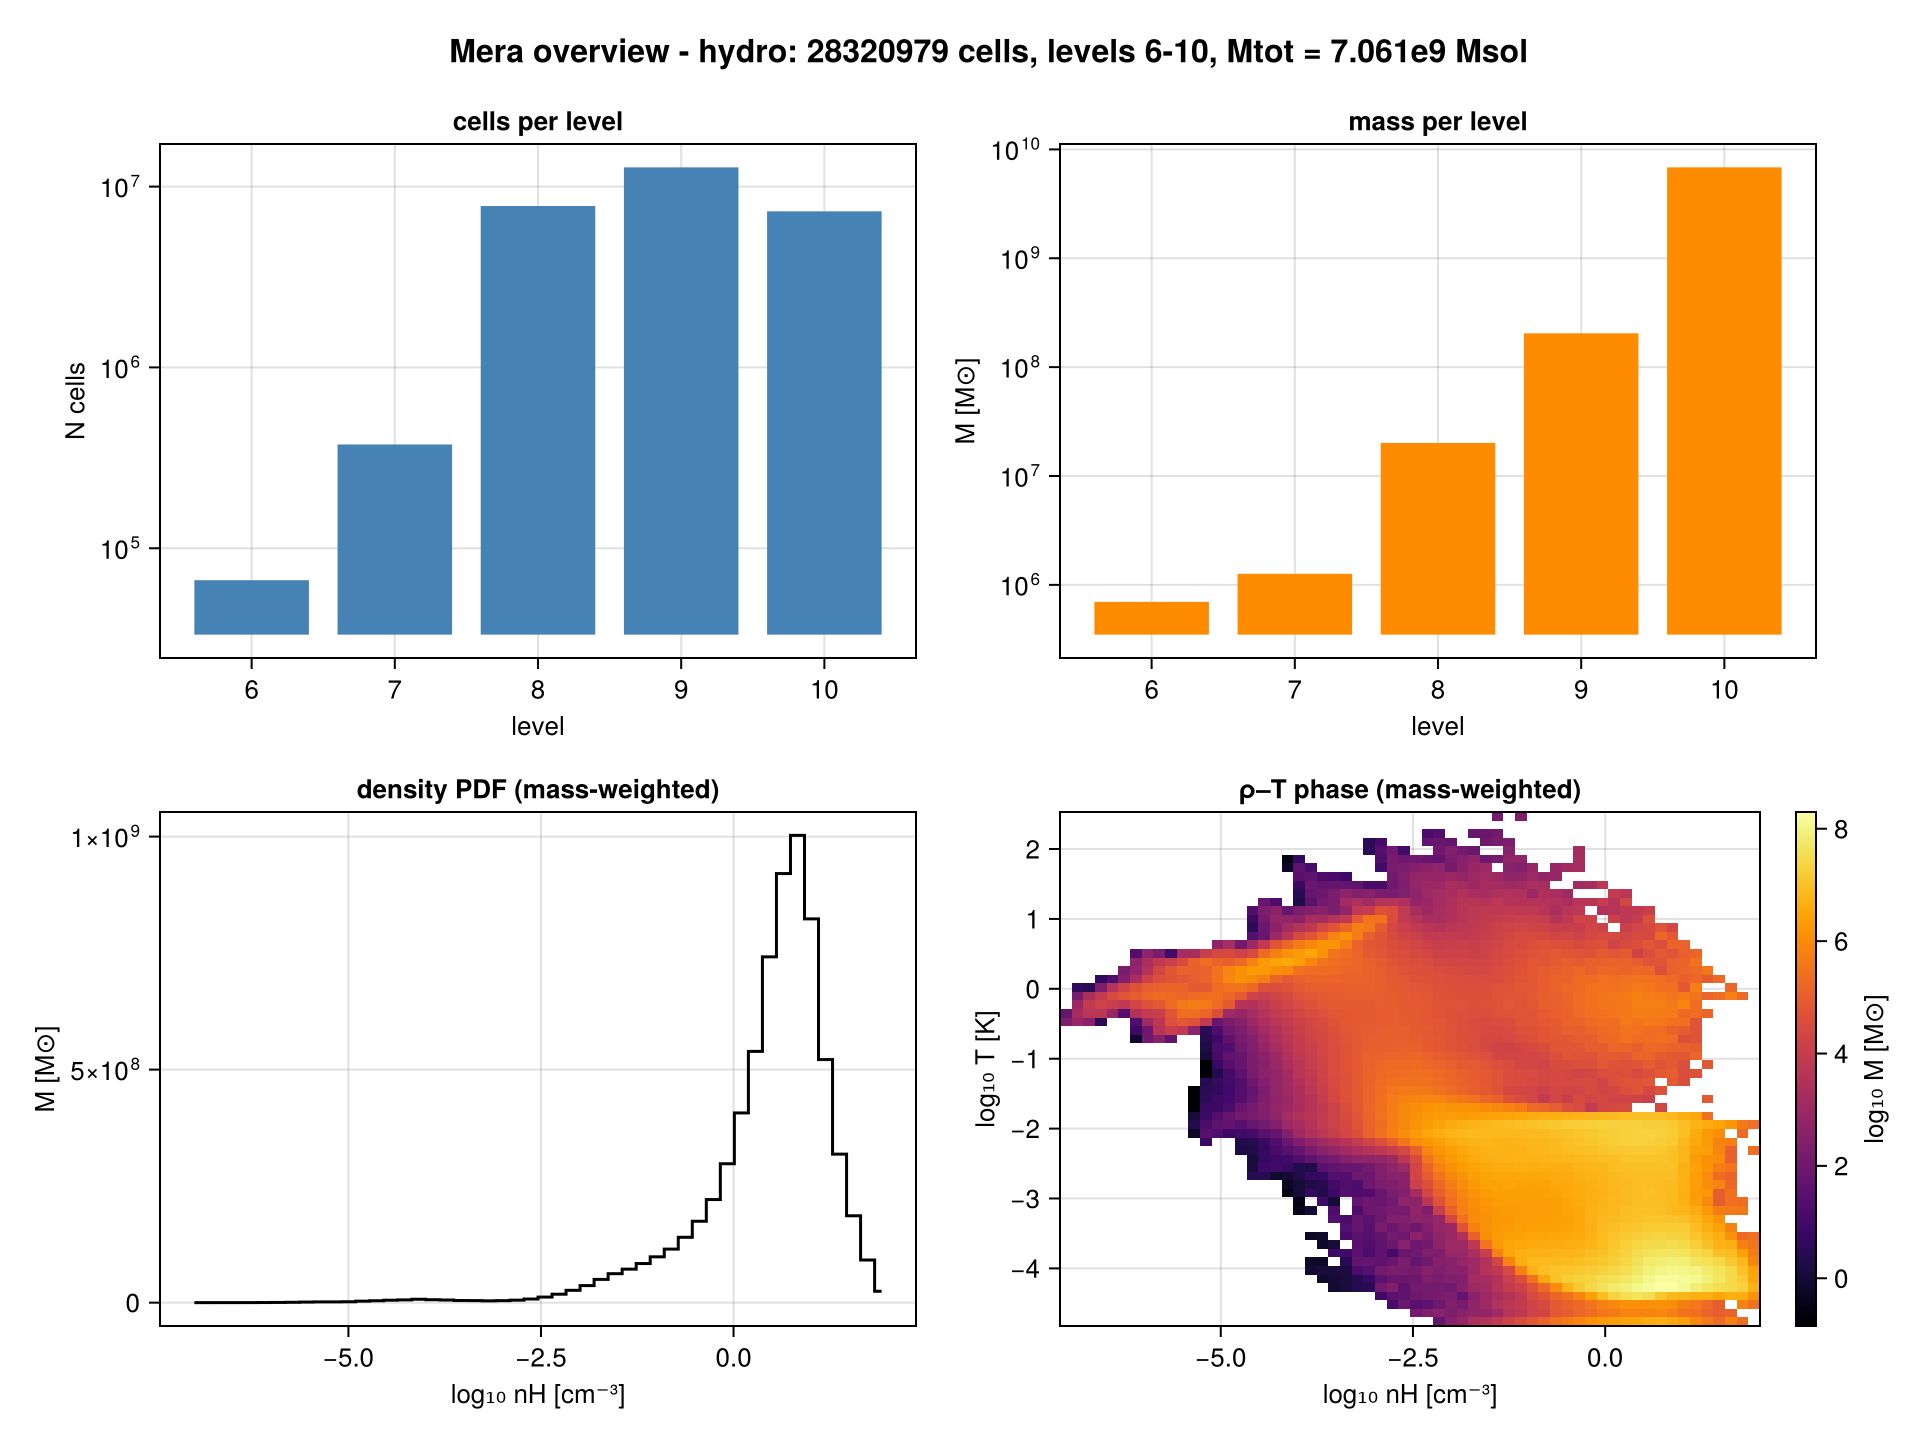

In [18]:
using CairoMakie
overviewplot(gas)

### Statistical Data Analysis

The `dataoverview()` function computes comprehensive statistics for all hydro variables in our dataset. This analysis provides:

- **Variable ranges** - Minimum and maximum values for each quantity

The calculated information is stored in code units and can be accessed for further analysis:

In [19]:
data_overview = dataoverview(gas)

Calculating...


  40%|████████████████████▍                              |  ETA: 0:01:37

  60%|██████████████████████████████▋                    |  ETA: 0:01:10

  80%|████████████████████████████████████████▊          |  ETA: 0:00:38

 100%|███████████████████████████████████████████████████| Time: 0:03:13

Table with 5 rows, 16 columns:
Columns:
#   colname        type
───────────────────────
1   level          Any
2   mass           Any
3   rho_min        Any
4   rho_max        Any
5   vx_min         Any
6   vx_max         Any
7   vy_min         Any
8   vy_max         Any
9   vz_min         Any
10  vz_max         Any
11  p_min          Any
12  p_max          Any
13  scalar_00_min  Any
14  scalar_00_max  Any
15  scalar_01_min  Any
16  scalar_01_max  Any

### Working with IndexedTables

When dealing with tables containing many columns, only a summary view is typically displayed. To access specific columns, use the `select()` function.

**Important Notes:**
- Column names are specified as quoted Symbols (`:column_name`)  
- For more details, see the [Julia documentation on Symbols](https://docs.julialang.org/en/v1/manual/metaprogramming/#Symbols-1)
- The `select()` function maintains data order and relationships

Let's select specific columns to examine level-wise mass and density statistics:

In [20]:
using Mera.IndexedTables # to import the IndexedTables package, which is a dependency of Mera

In [21]:
select(data_overview, (:level,:mass, :rho_min, :rho_max ) )

Table with 5 rows, 4 columns:
level  mass         rho_min     rho_max
───────────────────────────────────────────
6      0.000698165  2.61776e-9  1.16831e-7
7      0.00126374   1.15139e-8  2.21103e-7
8      0.0201245    2.44071e-8  0.000222309
9      0.204407     1.2142e-7   0.0141484
10     6.83618      4.49036e-7  3.32984

### Unit Conversion Example

Extract mass data from a specific column and convert it to solar masses. The `column()` function retrieves data from a specific table column, maintaining the order consistent with the table structure:

In [22]:
column(data_overview, :mass) * info.scale.Msol 

5-element Vector{Float64}:
 697971.5415380469
      1.2633877595077453e6
      2.01189316548175e7
      2.0435047070331135e8
      6.834288803451587e9

### In-Place Unit Conversion

Alternatively, you can directly convert the data within the table using the `transform()` function. This modifies the table in-place, converting the `:mass` column to solar mass units:

In [23]:
data_overview = transform(data_overview, :mass => :mass => value->value * info.scale.Msol);

In [24]:
select(data_overview, (:level, :mass, :rho_min, :rho_max ) )

Table with 5 rows, 4 columns:
level  mass       rho_min     rho_max
─────────────────────────────────────────
6      6.97972e5  2.61776e-9  1.16831e-7
7      1.26339e6  1.15139e-8  2.21103e-7
8      2.01189e7  2.44071e-8  0.000222309
9      2.0435e8   1.2142e-7   0.0141484
10     6.83429e9  4.49036e-7  3.32984

## Data Structure Deep Dive

Now let's examine the detailed structure of our hydro data. Understanding this organization is crucial for effective data manipulation and analysis.

### IndexedTables Storage Format

The data is stored in `gas.data` as an **IndexedTables** table (in code units), which provides several key advantages:

- **Row-based organization**: Each row represents a single cell in the simulation
- **Column-based access**: Each column represents a specific physical property  
- **Efficient operations**: Built-in support for filtering, mapping, and aggregation
- **Memory efficiency**: Optimized storage and access patterns
- **Functional interface**: Clean, composable operations for data manipulation

For comprehensive information on working with this data structure:
- Mera.jl documentation and tutorials
- [JuliaDB API Reference](https://juliadb.juliadata.org/latest/)
- IndexedTables.jl documentation

### Understanding the Data Layout

The table structure reflects the AMR grid organization:

**Spatial Coordinates**
- **Integer cell positions** (cx, cy, cz) form a uniform 3D array within each refinement level
- **Level-specific ranges**: Each refinement level has its own coordinate system
  - Level 8: coordinates range from 1-256
  - Level 14: coordinates range from 1-16384  
- **Sparse occupancy**: Not all coordinate positions exist due to adaptive refinement

**Critical Data Integrity Notes**
- **Coordinate preservation**: The integers cx, cy, cz are essential for grid reconstruction
- **Do not modify**: These coordinates maintain the AMR spatial relationships
- **Unique identifiers**: Each (level, cx, cy, cz) combination uniquely identifies a cell

Let's examine the complete data table:

In [25]:
gas.data

Table with 28320979 rows, 11 columns:
Columns:
#   colname    type
──────────────────────
1   level      Int64
2   cx         Int64
3   cy         Int64
4   cz         Int64
5   rho        Float64
6   vx         Float64
7   vy         Float64
8   vz         Float64
9   p          Float64
10  scalar_00  Float64
11  scalar_01  Float64

### Focused Data Examination

For a more detailed view of specific columns, we can select key fields to understand the data organization better:

In [26]:
select(gas.data, (:level,:cx, :cy, :cz, :rho) )

Table with 28320979 rows, 5 columns:
level  cx   cy   cz   rho
─────────────────────────────────
6      1    1    1    3.18647e-9
6      1    1    2    3.58591e-9
6      1    1    3    3.906e-9
6      1    1    4    4.27441e-9
6      1    1    5    4.61042e-9
6      1    1    6    4.83977e-9
6      1    1    7    4.974e-9
6      1    1    8    5.08112e-9
6      1    1    9    5.20596e-9
6      1    1    10   5.38372e-9
6      1    1    11   5.67209e-9
6      1    1    12   6.14423e-9
⋮
10     814  493  514  0.000321702
10     814  494  509  1.42963e-6
10     814  494  510  1.4351e-6
10     814  494  511  0.00029515
10     814  494  512  0.000395273
10     814  494  513  0.000321133
10     814  494  514  0.000319678
10     814  495  511  0.00024646
10     814  495  512  0.000269009
10     814  496  511  0.000235329
10     814  496  512  0.000242422

## Summary and Next Steps

### What You've Learned

In this tutorial, you've mastered the fundamentals of working with hydrodynamic data in Mera.jl:

1. **Data Loading**: How to load hydro data using `gethydro()` with various options
2. **Structure Understanding**: The organization of AMR grids and IndexedTables
3. **Variable Management**: Working with predefined and custom variable names
4. **Data Analysis**: Using `amroverview()` and `dataoverview()` for comprehensive analysis
5. **Unit Handling**: Converting between code units and physical units
6. **Memory Management**: Monitoring and optimizing memory usage
7. **Data Manipulation**: Using IndexedTables operations for efficient data processing

### Key Takeaways

- Hydro data is stored in IndexedTables format for efficient access and manipulation
- AMR coordinates (level, cx, cy, cz) are critical for spatial relationships
- Always be conscious of units - raw data is in code units
- Memory management is crucial for large datasets
- Mera.jl provides powerful tools for statistical analysis and data exploration

### Continue Your Learning

Now that you understand hydro data fundamentals, you can explore:

- **Advanced hydro analysis**: Spatial filtering, custom calculations, and derived quantities
- **Data visualization**: Creating plots and visualizations of your hydro data
- **Multi-physics analysis**: Combining hydro data with gravity and particle data
- **Time series analysis**: Working with multiple simulation outputs
- **Performance optimization**: Advanced techniques for large-scale data processing